In [1]:
!pip install deepface opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.6 MB/s eta 0:00:00


26-07-07 14:43:35 - Directory /root/.deepface has been created
26-07-07 14:43:35 - Directory /root/.deepface/weights has been created


Saving img4.jpg to img4.jpg
26-07-07 14:44:37 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:00<00:00, 80.4MB/s]


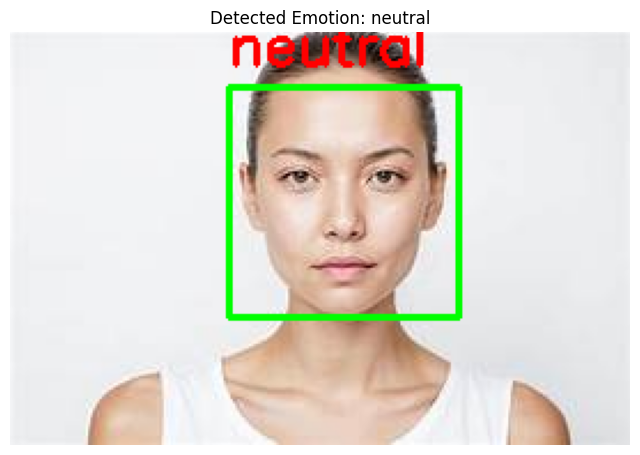

Detected Emotion: neutral


In [2]:
from deepface import DeepFace
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload Image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Analyze Image
result = DeepFace.analyze(
    img_path=image_path,
    actions=['emotion'],
    enforce_detection=False
)

# Read Image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Face Coordinates
face = result[0]['region']
x, y, w, h = face['x'], face['y'], face['w'], face['h']

# Draw Rectangle
cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)

# Emotion Text
emotion = result[0]['dominant_emotion']
cv2.putText(img, emotion, (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8, (255,0,0), 2)

# Show Image
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')
plt.title(f"Detected Emotion: {emotion}")
plt.show()

print("Detected Emotion:", emotion)